In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize

In [2]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

In [3]:
def compute_loss(theta,X,y):
     m = len(y)
     hx = sigmoid(np.dot(X, theta))

    # Clip hx to avoid log(0)
     epsilon = 1e-9  # Small constant
     hx = np.clip(hx, epsilon, 1 - epsilon)

     cos = -(y * np.log(hx) + (1 - y) * np.log(1 - hx)) / m # here cos is numpy array 
     return np.sum(cos) 

In [4]:
def compute_gradient(theta,X,y):
    hx = sigmoid(np.dot(X,theta))
    return np.dot(X.T,(hx-y))/len(y)

In [5]:
def expand_feature(x1,x2,power = 2):
    new_x = np.ones((x1.shape[0],1))  #1 column (bias term)
    for i in range(1,power+1):
        for j in range(i+1):
            new_x = np.append(new_x,(x1**(i-j)*(x2**j)).reshape(-1,1),axis = 1)
            # this reshape is very important as it changes the 1D vector to column vectoe
    return new_x

In [6]:
def gradient_decent(X,y,theta,alpha,num_iters):
    m = len(y)
    costs = []

    for i in range(num_iters):
        h = sigmoid(np.dot(X,theta))
        error = h - y  # Ensure y is (m,1)
        gradient = np.dot(X.T,error)
        theta -= alpha*gradient
        costs.append(compute_loss(theta,X,y))

    return theta,costs

In [7]:
def predict(theta,X):
    return (sigmoid(np.dot(X,theta))>0.5).flatten()

In [8]:
df = pd.read_csv('circular_logistic_regression_dataset.csv')

In [9]:
df.head()

,x1,x2,y
0,-0.375312,0.213451,1
1,-0.067487,1.006769,0
2,-0.343097,0.024870,1
3,-0.611725,-0.631407,0
4,-0.789013,0.684519,0


In [10]:
X = np.array([df['x1'],df['x2']]).T
y = np.array(df['y'])

In [11]:
y = y.reshape(-1,1)

In [12]:
y.shape

(500, 1)

In [13]:
df['x1'].shape[0]

500

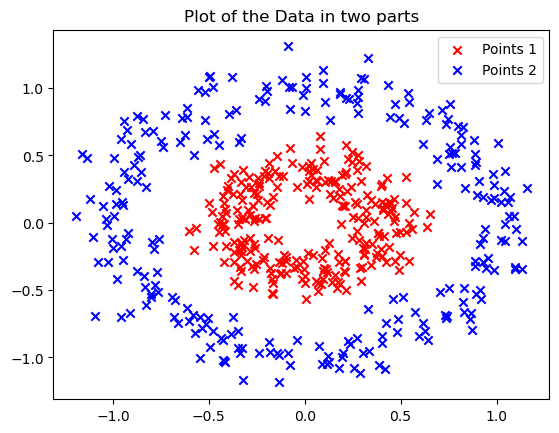

In [14]:
plt.scatter(df['x1'][df['y']==1],df['x2'][df['y']==1],c = 'red',marker='x',label = 'Points 1')
plt.scatter(df['x1'][df['y']==0],df['x2'][df['y']==0],c = 'blue',marker='x',label = 'Points 2')
plt.title("Plot of the Data in two parts")
plt.legend()
plt.show()

In [15]:
def logistic_regression(X,y,power = 2,alpha = 0.01,num_iters = 100 ):
    X = expand_feature(X[:,0],X[:,1],power=power)
    print(X.shape)
    theta = np.zeros((X.shape[1],1),dtype=np.float64)
    theta,costs = gradient_decent(X,y,theta,alpha,num_iters)
    predicted = predict(theta,X)
    return predicted,theta,costs
    

In [16]:
power , num = 6,20000
predicted,theta,costs = logistic_regression(X,y,power,alpha=0.6,num_iters=num)

(500, 28)


In [17]:
theta.shape

(28, 1)

In [18]:
predicted.shape

(500,)

In [19]:
y.shape

(500, 1)

In [20]:
print('The accuracy is {:.2f}%'.format(sum(predicted==y.flatten())/len(y)*100))

The accuracy is 100.00%


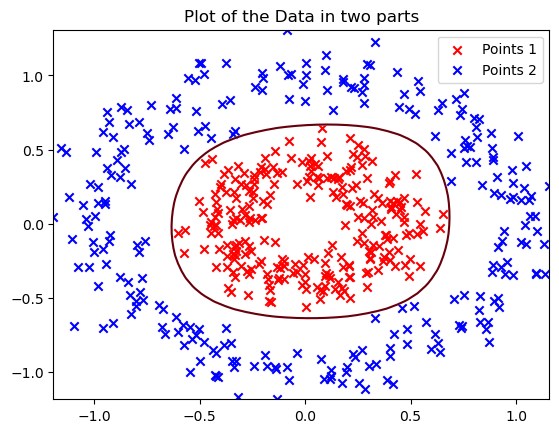

In [21]:
u = np.linspace(min(X[:,0]),max(X[:,0]),50)
v = np.linspace(min(X[:,1]),max(X[:,1]),50)

z = np.zeros((len(u),len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        z[i,j] = np.dot(expand_feature(u[i].reshape(-1,1),v[j].reshape(-1,1),power=power),theta).item()
z = np.transpose(z)
plt.contour(u,v,z,[0,0.01],cmap = 'Reds')
plt.scatter(df['x1'][df['y']==1],df['x2'][df['y']==1],c = 'red',marker='x',label = 'Points 1')
plt.scatter(df['x1'][df['y']==0],df['x2'][df['y']==0],c = 'blue',marker='x',label = 'Points 2')
plt.title("Plot of the Data in two parts")
plt.legend()
plt.show()


In [22]:
X.shape

(500, 2)